In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

In [2]:
def simulate_tracks(
    n_planes,
    spatial_resolution,
    n_tracks=1000,
    plane_size=100.0,
    start_area_fraction=0.10,
    z_min=0.0,
    z_max=600.0,
    theta_max_deg=10.0,
    beta_min=0.5,
    beta_max=0.75,
    time_resolution=2.0,
    tof_margin=50.0,
    default_value=-999999.0,
    seed=42
):
    """
    Simula tracce Monte Carlo con:
    - n_planes piani di tracciamento sensibili a x,y
    - 2 piani temporali, uno prima e uno dopo il tracciatore
    - velocità casuale tra beta_min*c e beta_max*c
    - controllo dell'accettanza geometrica dei piani

    Le hit fuori accettanza vengono riempite con default_value.

    Returns
    -------
    x_meas : np.ndarray
        Coordinate x misurate, shape = (n_tracks, n_planes).
        Se fuori accettanza: default_value.

    y_meas : np.ndarray
        Coordinate y misurate, shape = (n_tracks, n_planes).
        Se fuori accettanza: default_value.

    z_planes : np.ndarray
        Coordinate z dei piani di tracciamento, shape = (n_planes,)

    theta : np.ndarray
        Angolo polare generato rispetto all'asse z, in radianti.

    theta_deg : np.ndarray
        Angolo polare generato rispetto all'asse z, in gradi.

    beta : np.ndarray
        Velocità generata in unità di c.

    delta_t_meas : np.ndarray
        Differenza di tempo misurata tra i due piani temporali, in ns.

    hit_valid : np.ndarray
        Maschera booleana, shape = (n_tracks, n_planes).
        True se la hit è dentro l'accettanza del piano.
    """

    rng = np.random.default_rng(seed)

    # Velocità della luce in mm/ns
    c_mm_ns = 299.792458

    # Posizione dei piani di tracciamento
    z_planes = np.linspace(z_min, z_max, n_planes)

    # Posizione dei due piani temporali
    z_time_1 = z_min - tof_margin
    z_time_2 = z_max + tof_margin

    delta_z_tof = z_time_2 - z_time_1

    # Regione iniziale pari a start_area_fraction dell'area del piano
    start_size = plane_size * np.sqrt(start_area_fraction)
    start_half_size = start_size / 2

    x0 = rng.uniform(-start_half_size, start_half_size, n_tracks)
    y0 = rng.uniform(-start_half_size, start_half_size, n_tracks)

    # Angoli casuali entro un cono attorno all'asse z
    theta_max = np.deg2rad(theta_max_deg)

    phi = rng.uniform(0, 2 * np.pi, n_tracks)

    # Distribuzione uniforme in angolo solido
    cos_theta = rng.uniform(np.cos(theta_max), 1, n_tracks)
    theta = np.arccos(cos_theta)
    theta_deg = np.rad2deg(theta)

    tan_theta = np.tan(theta)

    tx = tan_theta * np.cos(phi)   # dx/dz
    ty = tan_theta * np.sin(phi)   # dy/dz

    # Velocità casuale
    beta = rng.uniform(beta_min, beta_max, n_tracks)

    # Hit vere sui piani di tracciamento
    x_true = x0[:, None] + tx[:, None] * z_planes[None, :]
    y_true = y0[:, None] + ty[:, None] * z_planes[None, :]

    # Maschera di accettanza geometrica
    half_plane_size = plane_size / 2

    hit_valid = (
        (np.abs(x_true) <= half_plane_size) &
        (np.abs(y_true) <= half_plane_size)
    )

    # Hit misurate con risoluzione spaziale gaussiana
    x_meas = x_true + rng.normal(
        0,
        spatial_resolution,
        size=x_true.shape
    )

    y_meas = y_true + rng.normal(
        0,
        spatial_resolution,
        size=y_true.shape
    )

    # Se la traccia è fuori accettanza, il piano non misura nessuna hit
    x_meas[~hit_valid] = default_value
    y_meas[~hit_valid] = default_value

    # Tempo di volo vero tra i due piani temporali
    path_length = delta_z_tof / np.cos(theta)
    delta_t_true = path_length / (beta * c_mm_ns)

    # Misura del tempo sui due piani temporali
    t1_meas = rng.normal(0, time_resolution, n_tracks)
    t2_meas = delta_t_true + rng.normal(0, time_resolution, n_tracks)

    delta_t_meas = t2_meas - t1_meas

    return x_meas, y_meas, z_planes, theta, theta_deg, beta, delta_t_meas

In [3]:
#simulazione
x_hits, y_hits, z_planes, theta, theta_deg, beta, delta_t_meas = simulate_tracks(
    n_planes=7,
    spatial_resolution=0.1,   # mm = 100 um
    time_resolution=0.3,      # ns
    tof_margin=50.0           # mm
)

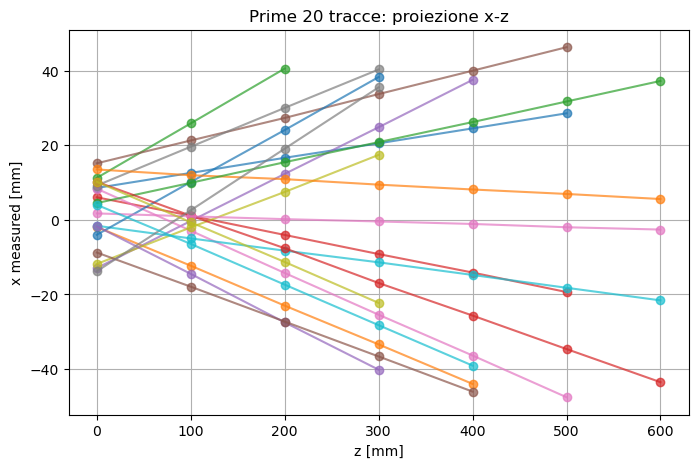

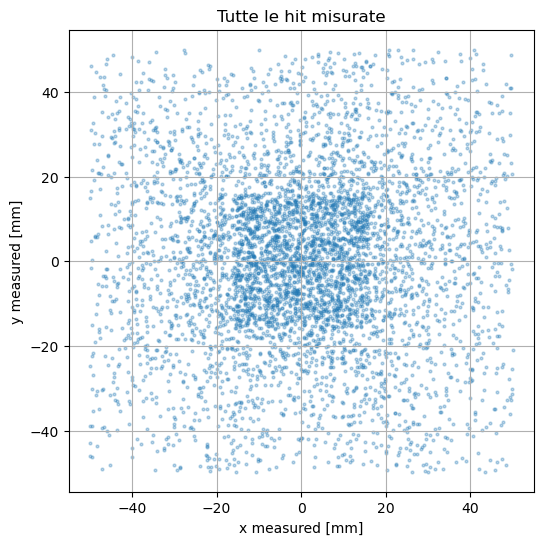

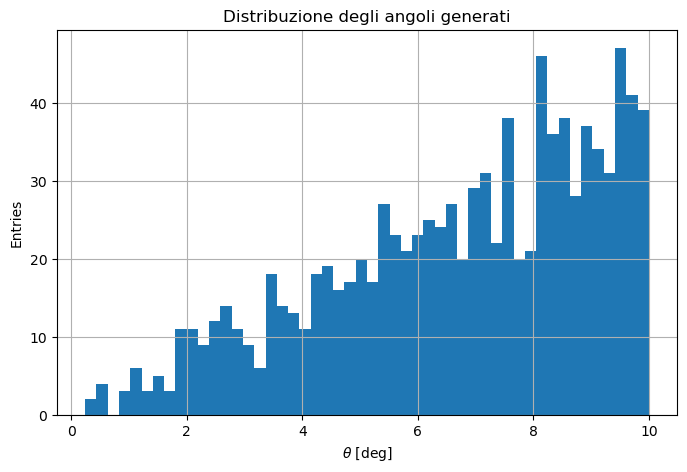

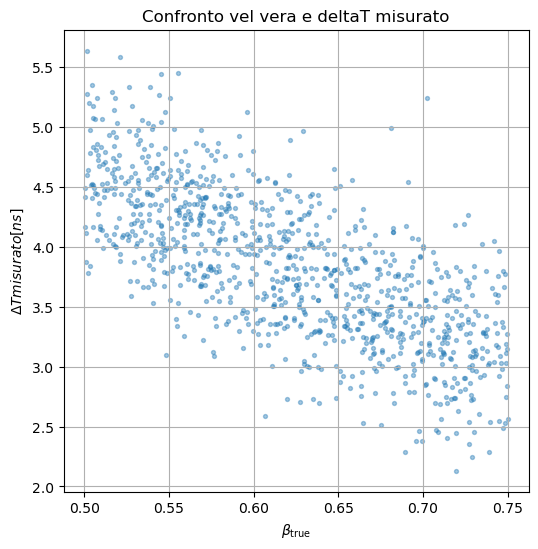

In [8]:
# debug plots

mask = (x_hits > -999) & (y_hits > -999)

# prime 20 tracce ricostruite
n_show = 20
plt.figure(figsize=(8, 5))

for i in range(n_show):
    plt.plot(
        z_planes[mask[i]],
        x_hits[i][mask[i]],
        marker="o",
        alpha=0.7
    )

plt.xlabel("z [mm]")
plt.ylabel("x measured [mm]")
plt.title(f"Prime {n_show} tracce: proiezione x-z")
plt.grid(True)
plt.show()


# distribuzione hit ricostruite
plt.figure(figsize=(6, 6))

plt.scatter(
    x_hits[mask],
    y_hits[mask],
    s=4,
    alpha=0.3
)

plt.xlabel("x measured [mm]")
plt.ylabel("y measured [mm]")
plt.title("Tutte le hit misurate")
plt.axis("equal")
plt.grid(True)
plt.show()


# distribuzione angoli generati
plt.figure(figsize=(8, 5))
plt.hist(theta_deg, bins=50)

plt.xlabel(r"$\theta$ [deg]")
plt.ylabel("Entries")
plt.title("Distribuzione degli angoli generati")
plt.grid(True)
plt.show()


plt.figure(figsize=(6, 6))

plt.scatter(beta, delta_t_meas, s=8, alpha=0.4)

plt.xlabel(r"$\beta_{\mathrm{true}}$")
plt.ylabel(r"$\Delta T misurato [ns]$")
plt.title("Confronto vel vera e deltaT misurato")
plt.grid(True)
plt.show()

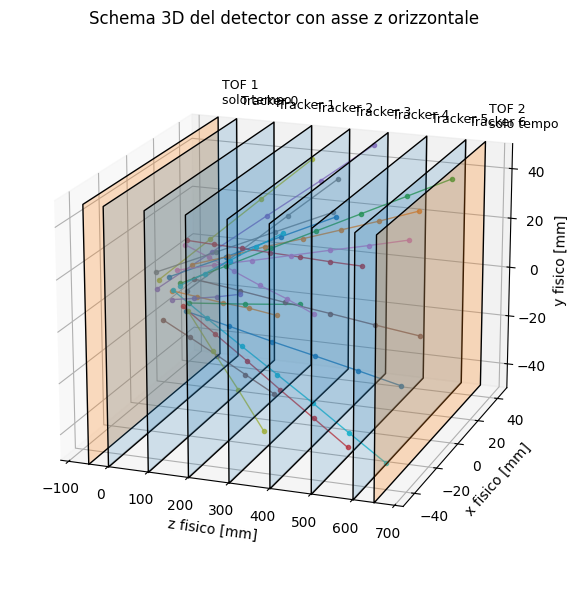

In [50]:
#Disegna geometria


def draw_detector(
    z_planes,
    plane_size=100.0,
    tof_margin=50.0,
    x_hits=None,
    y_hits=None,
    n_tracks_show=20
):
    """
    Disegna il detector in 3D usando la coordinata fisica z
    come asse orizzontale del grafico.

    Mapping del plot:
        asse X grafico = z fisico
        asse Y grafico = x fisico
        asse Z grafico = y fisico
    """

    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection="3d")

    half_size = plane_size / 2

    z_tracker_min = z_planes[0]
    z_tracker_max = z_planes[-1]

    z_time_1 = z_tracker_min - tof_margin
    z_time_2 = z_tracker_max + tof_margin

    def add_plane(z_phys, label, facecolor, alpha=0.25):
        """
        Piano fisico perpendicolare a z.
        Nel plot viene disegnato a X = z_phys,
        esteso lungo Y = x e Z = y.
        """

        vertices = [
            [
                (z_phys, -half_size, -half_size),
                (z_phys,  half_size, -half_size),
                (z_phys,  half_size,  half_size),
                (z_phys, -half_size,  half_size),
            ]
        ]

        plane = Poly3DCollection(
            vertices,
            facecolors=facecolor,
            edgecolors="black",
            linewidths=1.0,
            alpha=alpha
        )

        ax.add_collection3d(plane)

        ax.text(
            z_phys,
            half_size * 1.08,
            half_size * 1.08,
            label,
            fontsize=9
        )

    # Primo piano temporale
    add_plane(
        z_time_1,
        "TOF 1\nsolo tempo",
        facecolor="tab:orange",
        alpha=0.25
    )

    # Piani di tracciamento
    for i, z in enumerate(z_planes):
        add_plane(
            z,
            f"Tracker {i}",
            facecolor="tab:blue",
            alpha=0.18
        )

    # Secondo piano temporale
    add_plane(
        z_time_2,
        "TOF 2\nsolo tempo",
        facecolor="tab:orange",
        alpha=0.25
    )

    # Disegna alcune tracce
    if x_hits is not None and y_hits is not None:
        n_tracks = x_hits.shape[0]
        n_show = min(n_tracks_show, n_tracks)

        for i in range(n_show):
            ax.plot(
                z_planes,      # asse X grafico = z fisico
                x_hits[i],     # asse Y grafico = x fisico
                y_hits[i],     # asse Z grafico = y fisico
                marker="o",
                markersize=3,
                linewidth=1,
                alpha=0.8
            )

    # Limiti degli assi
    z_min_plot = z_time_1 - 0.1 * abs(z_time_2 - z_time_1)
    z_max_plot = z_time_2 + 0.1 * abs(z_time_2 - z_time_1)

    ax.set_xlim(z_min_plot, z_max_plot)
    ax.set_ylim(-half_size, half_size)
    ax.set_zlim(-half_size, half_size)

    ax.set_xlabel("z fisico [mm]")
    ax.set_ylabel("x fisico [mm]")
    ax.set_zlabel("y fisico [mm]")

    ax.set_title("Schema 3D del detector con asse z orizzontale")

    # Vista scelta per mostrare z orizzontale
    ax.view_init(elev=18, azim=-70)

    plt.tight_layout()
    plt.show()


draw_detector(
    z_planes=z_planes,
    plane_size=100.0,
    tof_margin=50.0,
    x_hits=x_hits,
    y_hits=y_hits,
    n_tracks_show=20
)